# Dataset

Download the dataset and save it to a directory at per your convience. [IMDB comments](https://github.com/abulbasar/data/blob/master/imdb-comments.json.zip?raw=true)

In [4]:
import pandas as pd # Used for dataframe functions
import json # parse json string
import nltk # Natural language toolkit for TDIDF etc.
from bs4 import BeautifulSoup # Parse html string .. to extract text
import re # Regex parser 
import numpy as np # Linear algebbra 
from sklearn import * # machine learning
import matplotlib.pyplot as plt # Visualization



import scipy #Sparse matrix 

np.set_printoptions(precision=4)
pd.options.display.max_columns = 1000
pd.options.display.max_rows = 10
pd.options.display.float_format = lambda f: "%.4f" % f

%matplotlib inline 


Bad key "text.kerning_factor" on line 4 in
/Users/abasar/anaconda3/lib/python3.7/site-packages/matplotlib/mpl-data/stylelib/_classic_test_patch.mplstyle.
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.1.3/matplotlibrc.template
or from the matplotlib source distribution


Run the following lines when you run this notebook first time on your system.

In [2]:
import nltk
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download('averaged_perceptron_tagger')
nltk.download("vader_lexicon") 

[nltk_data] Downloading package punkt to /Users/abasar/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/abasar/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/abasar/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/abasar/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/abasar/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [3]:
print(nltk.__version__)

3.4.5


Now let's see how to create text classifier using nltk and scikit learn.

In [4]:
# Dataset: https://github.com/abulbasar/data/blob/master/imdb-comments.json.zip

In [5]:
# The following line does not work on Windows system
!head -n 1 /Users/abasar/data/imdb-comments.json

{"label":"test","sentiment":"pos","name":"0_10.txt","content":"I went and saw this movie last night after being coaxed to by a few friends of mine. I'll admit that I was reluctant to see it because from what I knew of Ashton Kutcher he was only able to do comedy. I was wrong. Kutcher played the character of Jake Fischer very well, and Kevin Costner played Ben Randall with such professionalism. The sign of a good movie is that it can toy with our emotions. This one did exactly that. The entire theater (which was sold out) was overcome by laughter during the first half of the movie, and were moved to tears during the second half. While exiting the theater I not only saw many women in tears, but many full grown men as well, trying desperately not to let anyone see them crying. This movie was great, and I suggest that you go see it before you judge."}


In [6]:
data = []
with open("/Users/abasar/data/imdb-comments.json", "r", encoding="utf8") as f:
    for l in f.readlines():
        data.append(json.loads(l))    

In [7]:
comments = pd.DataFrame.from_dict(data)
comments.sample(10)

,label,sentiment,name,content
45611,train,neg,6050_4.txt,I simply cannot believe the number of people c...
16647,test,neg,2483_4.txt,This show had a promising start as sort of the...
44255,train,neg,4830_2.txt,REALLY? REALLY???? I know if you make a politi...
27334,train,pos,12100_8.txt,"The DVD for ""Danaza Macabra"" (Castle of Blood)..."
41184,train,neg,2066_2.txt,"After two long, long opening skits, one of whi..."
22101,test,neg,7392_1.txt,"I went to see ""TKIA"" with high expectations, w..."
25228,train,pos,10205_10.txt,"REnted this one accidentally, it was behind th..."
33962,train,pos,6817_10.txt,"I love the movie, it was a very interesting fa..."
11985,test,pos,9538_10.txt,...apparently Bernard Cribbins ad libbed nearl...
26193,train,pos,11074_7.txt,Neither the total disaster the UK critics clai...


In [8]:
comments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   label      50000 non-null  object
 1   sentiment  50000 non-null  object
 2   name       50000 non-null  object
 3   content    50000 non-null  object
dtypes: object(4)
memory usage: 1.5+ MB


In [9]:
comments.label.value_counts()

train    25000
test     25000
Name: label, dtype: int64

In [10]:
comments.groupby(["label", "sentiment"]).content.count().unstack()

sentiment,neg,pos
label,,
test,12500,12500
train,12500,12500


In [11]:
np.random.seed(1)
v = list(comments["content"].sample(1))[0]
v

'When we started watching this series on cable, I had no idea how addictive it would be. Even when you hate a character, you hold back because they are so beautifully developed, you can almost understand why they react to frustration, fear, greed or temptation the way they do. It\'s almost as if the viewer is experiencing one of Christopher\'s learning curves.<br /><br />I can\'t understand why Adriana would put up with Christopher\'s abuse of her, verbally, physically and emotionally, but I just have to read the newspaper to see how many women can and do tolerate such behavior. Carmella has a dream house, endless supply of expensive things, but I\'m sure she would give it up for a loving and faithful husband - or maybe not. That\'s why I watch.<br /><br />It doesn\'t matter how many times you watch an episode, you can find something you missed the first five times. We even watch episodes out of sequence (watch season 1 on late night with commercials but all the language, A&E with lang

In [12]:
comments.head()

,label,sentiment,name,content
0,test,pos,0_10.txt,I went and saw this movie last night after bei...
1,test,pos,10000_7.txt,Actor turned director Bill Paxton follows up h...
2,test,pos,10001_9.txt,As a recreational golfer with some knowledge o...
3,test,pos,10002_8.txt,"I saw this film in a sneak preview, and it is ..."
4,test,pos,10003_8.txt,Bill Paxton has taken the true story of the 19...


In [13]:
comments["content"].values[0]

"I went and saw this movie last night after being coaxed to by a few friends of mine. I'll admit that I was reluctant to see it because from what I knew of Ashton Kutcher he was only able to do comedy. I was wrong. Kutcher played the character of Jake Fischer very well, and Kevin Costner played Ben Randall with such professionalism. The sign of a good movie is that it can toy with our emotions. This one did exactly that. The entire theater (which was sold out) was overcome by laughter during the first half of the movie, and were moved to tears during the second half. While exiting the theater I not only saw many women in tears, but many full grown men as well, trying desperately not to let anyone see them crying. This movie was great, and I suggest that you go see it before you judge."

# Vader Sentiment Analysis

In [14]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

In [15]:
sia.polarity_scores(comments["content"].values[0])

{'neg': 0.085, 'neu': 0.775, 'pos': 0.14, 'compound': 0.7956}

In [16]:
def sentiment_score(text):
    return sia.polarity_scores(text)["compound"]

sentiment_score(comments["content"].values[0])

0.7956

In [17]:
%%time 
comments["vader_score"] = comments["content"].apply(lambda text: sentiment_score(text))

CPU times: user 2min 2s, sys: 985 ms, total: 2min 3s
Wall time: 2min 5s


In [18]:
comments["vader_sentiment"] = np.where(comments["vader_score"]>0, "pos", "neg")

In [19]:
comments.head()

,label,sentiment,name,content,vader_score,vader_sentiment
0,test,pos,0_10.txt,I went and saw this movie last night after bei...,0.7956,pos
1,test,pos,10000_7.txt,Actor turned director Bill Paxton follows up h...,0.9948,pos
2,test,pos,10001_9.txt,As a recreational golfer with some knowledge o...,0.9726,pos
3,test,pos,10002_8.txt,"I saw this film in a sneak preview, and it is ...",0.9266,pos
4,test,pos,10003_8.txt,Bill Paxton has taken the true story of the 19...,0.9906,pos


In [20]:
comments.vader_sentiment.value_counts()

pos    33008
neg    16992
Name: vader_sentiment, dtype: int64

In [21]:
print(metrics.classification_report(comments["sentiment"], comments["vader_sentiment"]))

              precision    recall  f1-score   support

         neg       0.79      0.54      0.64     25000
         pos       0.65      0.86      0.74     25000

    accuracy                           0.70     50000
   macro avg       0.72      0.70      0.69     50000
weighted avg       0.72      0.70      0.69     50000



As we see above the accuracy is the range of 0.70. Vader model performed better for the positive sentiment compared to negative sentiment. Let's now use statistical model using TFIDF which generally perform better. 

# Sentiment Analysis using statistical model using TFIDF (term frequency, and inverse document frequency)

In [22]:
def preprocess(text):
    
    # Remove html tags
    # Lower case values 
    text = BeautifulSoup(text.lower(), "html5lib").text 
    
    # Replace the occurrences of multiple consecutive non-word characters (punctuation marks) 
    # with a single space (" ")
    text = re.sub(r"[\W]+", " ", text)
    return text

preprocess(v)

'when we started watching this series on cable i had no idea how addictive it would be even when you hate a character you hold back because they are so beautifully developed you can almost understand why they react to frustration fear greed or temptation the way they do it s almost as if the viewer is experiencing one of christopher s learning curves i can t understand why adriana would put up with christopher s abuse of her verbally physically and emotionally but i just have to read the newspaper to see how many women can and do tolerate such behavior carmella has a dream house endless supply of expensive things but i m sure she would give it up for a loving and faithful husband or maybe not that s why i watch it doesn t matter how many times you watch an episode you can find something you missed the first five times we even watch episodes out of sequence watch season 1 on late night with commercials but all the language a e with language censored reruns on the movie network whenever 

In [23]:
%%time
# Apply the preprocessing logic to all comments
comments["content"] = comments["content"].apply(preprocess)

CPU times: user 39.3 s, sys: 149 ms, total: 39.5 s
Wall time: 39.6 s


In [24]:
comments_train = comments[comments["label"] == "train"]
comments_train.sample(10)

,label,sentiment,name,content,vader_score,vader_sentiment
25496,train,pos,10447_10.txt,there are many people in our lives that we mee...,0.9814,pos
41520,train,neg,2369_4.txt,sixth escapade for freddy krueger in which he ...,0.9802,pos
48525,train,neg,8674_2.txt,the first few minutes of the bodyguard do have...,0.4435,pos
26037,train,pos,10934_10.txt,after reviewing this intense martial arts movi...,0.6862,pos
43823,train,neg,4441_3.txt,triumph of love is proof that not every coméd...,0.9217,pos
39666,train,neg,11950_2.txt,this is without a doubt the worst movie i have...,0.1877,pos
40882,train,neg,1795_2.txt,i had the opportunity to preview this film as ...,0.6735,pos
43156,train,neg,3841_1.txt,roeg has done some great movies but this a tur...,0.6858,pos
37185,train,pos,9718_7.txt,possible spoiler in some way how to alienate f...,0.9909,pos
40330,train,neg,1298_3.txt,sogo ishii can be a skilled filmmaker under th...,-0.9517,neg


In [25]:
comments_test = comments[comments["label"] == "test"]
comments_test.sample(10)

,label,sentiment,name,content,vader_score,vader_sentiment
21277,test,neg,6650_1.txt,this is one of those movies where i was rootin...,-0.9583,neg
12620,test,neg,10108_1.txt,spoilersi m going to be as kind as i can about...,-0.1144,neg
4485,test,pos,2788_9.txt,as a former erasmus student i enjoyed this fil...,0.9514,pos
4744,test,pos,301_10.txt,francis ford coppola s masterpiece was a great...,-0.8899,neg
10329,test,pos,8047_10.txt,some of the reviewers here have foolishly judg...,0.9353,pos
14366,test,neg,11680_1.txt,this is by far one of the most pretentious fil...,-0.0498,neg
1007,test,pos,10907_8.txt,this is truly a funny movie his dance scene do...,0.9489,pos
4539,test,pos,2836_8.txt,this film released in 1951 has the usual eleme...,0.1714,pos
7864,test,pos,5829_10.txt,one of the best tv shows out there if not the ...,0.9692,pos
19582,test,neg,5124_4.txt,this movie was jerry bruckheimer s idea to sel...,0.9559,pos


In [26]:
X_train = comments_train["content"].values
y_train = np.where(comments_train.sentiment == "pos", 1, 0)

In [27]:
X_test = comments_test["content"].values
y_test = np.where(comments_test.sentiment == "pos", 1, 0)

In [2]:
# http://snowball.tartarus.org/algorithms/porter/stemmer.html
# http://www.nltk.org/howto/stem.html

from nltk.stem.snowball import SnowballStemmer # slight more aadvanced
from nltk.stem.porter import PorterStemmer
print(SnowballStemmer.languages)

('arabic', 'danish', 'dutch', 'english', 'finnish', 'french', 'german', 'hungarian', 'italian', 'norwegian', 'porter', 'portuguese', 'romanian', 'russian', 'spanish', 'swedish')


In [9]:
porter = PorterStemmer()
snowball = SnowballStemmer("english")
lemmatizer = nltk.wordnet.WordNetLemmatizer()

pd.options.display.max_rows = None

values = []


# Following are for illustration point of view
for s in nltk.word_tokenize("""
            revival
            allowance 
            inference 
            relational
            runner
            running
            runs
            ran
            has
            having
            generously
            wasn't
            leaves
            swimming
            relative
            relating
            """):
    values.append((s, porter.stem(s)
          , snowball.stem(s), lemmatizer.lemmatize(s, "v")))
    
pd.DataFrame(values, columns = ["original", "porter", "snowball", "lemmatizer"])

,original,porter,snowball,lemmatizer
0,revival,reviv,reviv,revival
1,allowance,allow,allow,allowance
2,inference,infer,infer,inference
3,relational,relat,relat,relational
4,runner,runner,runner,runner
5,running,run,run,run
6,runs,run,run,run
7,ran,ran,ran,run
8,has,ha,has,have
9,having,have,have,have


In [30]:
stopwords = nltk.corpus.stopwords.words("english")
print(len(stopwords), stopwords)

179 ['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're", "you've", "you'll", "you'd", 'your', 'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', "she's", 'her', 'hers', 'herself', 'it', "it's", 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves', 'what', 'which', 'who', 'whom', 'this', 'that', "that'll", 'these', 'those', 'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do', 'does', 'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until', 'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into', 'through', 'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once', 'here', 'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more', 'most', 'other', 'some', 'such', 'no', 'nor', 'not', 'only', 'own', 'same', 'so', 'than

Lets drop the following words from stopwords since they are likely good indicator of sentiment.

In [31]:
stopwords.remove("no")
stopwords.remove("nor")
stopwords.remove("not")

In [32]:
sentence = """Financial Services revenues increased $0.5 billion, or 5%, primarily due to
lower impairments and volume growth, partially offset by lower gains."""

stemmer = SnowballStemmer("english")
#stemmer = PorterStemmer()
def my_tokenizer(s):
    terms = nltk.word_tokenize(s.lower())
    #terms = re.split("\s", s.lower())
    #terms = [re.sub(r"[\.!]", "", v) for v in terms if len(v)>2]
    #terms = [v for v in terms if len(v)>2]
    terms = [v for v in terms if v not in stopwords]
    terms = [stemmer.stem(w) for w in terms]
    terms = [term for term in terms if len(term) > 2]
    return terms 
print(my_tokenizer(sentence))

['financi', 'servic', 'revenu', 'increas', '0.5', 'billion', 'primarili', 'due', 'lower', 'impair', 'volum', 'growth', 'partial', 'offset', 'lower', 'gain']


In [33]:
tfidf = feature_extraction.text.TfidfVectorizer(tokenizer=my_tokenizer, max_df = 0.99
                                                , min_df=0.01 
                                                , ngram_range=(1, 2))

corpus = ["Today is Wednesday"
          , "Delhi weather is hot today."
          , "Delhi roads are not busy in the morning"]

doc_term_matrix = tfidf.fit_transform(corpus)

# returns term and index in the feature matrix
print("Vocabulary: ", tfidf.vocabulary_) 

Vocabulary:  {'today': 12, 'wednesday': 16, 'today wednesday': 13, 'delhi': 2, 'weather': 14, 'hot': 5, 'delhi weather': 4, 'weather hot': 15, 'hot today': 6, 'road': 10, 'not': 8, 'busi': 0, 'morn': 7, 'delhi road': 3, 'road not': 11, 'not busi': 9, 'busi morn': 1}


In [34]:
columns = [None] * len(tfidf.vocabulary_)
for term in tfidf.vocabulary_:
    columns[tfidf.vocabulary_[term]] = term
columns
scores = pd.DataFrame(doc_term_matrix.toarray()
                      , columns= columns)
scores

,busi,busi morn,delhi,delhi road,delhi weather,hot,hot today,morn,not,not busi,road,road not,today,today wednesday,weather,weather hot,wednesday
0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.4736,0.6228,0.0000,0.0000,0.6228
1,0.0000,0.0000,0.3065,0.0000,0.4030,0.4030,0.4030,0.0000,0.0000,0.0000,0.0000,0.0000,0.3065,0.0000,0.4030,0.4030,0.0000
2,0.3414,0.3414,0.2597,0.3414,0.0000,0.0000,0.0000,0.3414,0.3414,0.3414,0.3414,0.3414,0.0000,0.0000,0.0000,0.0000,0.0000


In [35]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [36]:
X_test_tfidf.shape, y_test.shape, X_train_tfidf.shape, y_train.shape

((25000, 1773), (25000,), (25000, 1773), (25000,))

Let's estimate the memory requirment if the data is presented in dense matrix format

In [37]:
cell_count = np.product(X_train_tfidf.shape)
bytes = cell_count * 4 
GBs = bytes / (1024 ** 3) 
GBs

0.16512349247932434

In [38]:
sparsity = 1 - X_train_tfidf.count_nonzero() / cell_count
sparsity

0.9592606429780034

In [39]:
1 - X_train_tfidf.nnz / cell_count

0.9592606429780034

In [40]:
print("Type of doc_term_matrix", type(X_train_tfidf))

Type of doc_term_matrix <class 'scipy.sparse.csr.csr_matrix'>


Byte size of the training doc sparse doc

In [41]:
print(X_train_tfidf.data.nbytes / (1024.0 ** 3), "GB")

0.013454049825668335 GB


# Classification Model

In [42]:
%%time
lr = linear_model.LogisticRegression(C = 0.6, random_state = 1
                            , n_jobs = 8, solver="saga")
lr.fit(X_train_tfidf, y_train)
y_train_pred = lr.predict(X_train_tfidf)
y_test_pred = lr.predict(X_test_tfidf)
print("Training accuracy: ", metrics.accuracy_score(y_train, y_train_pred))
print("Test accuracy: ", metrics.accuracy_score(y_test, y_test_pred))

Training accuracy:  0.88768
Test accuracy:  0.87348
CPU times: user 519 ms, sys: 5.34 ms, total: 524 ms
Wall time: 534 ms


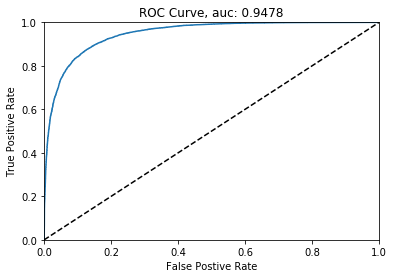

In [43]:
fpr, tpr, thresholds = metrics.roc_curve(y_test,
                        lr.predict_proba(X_test_tfidf)[:, [1]])
auc = metrics.auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.ylim(0, 1)
plt.xlim(0, 1)
plt.plot([0,1], [0,1], ls = "--", color = "k")
plt.xlabel("False Postive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve, auc: %.4f" % auc);

In [44]:
%%time
from sklearn import naive_bayes, ensemble
bayes = naive_bayes.MultinomialNB(alpha=1)
bayes.fit(X_train_tfidf, y_train)
print("accuracy: ", bayes.score(X_test_tfidf, y_test))

accuracy:  0.84596
CPU times: user 24.5 ms, sys: 1.59 ms, total: 26.1 ms
Wall time: 24.8 ms


In [45]:
%%time
est = tree.DecisionTreeClassifier()
est.fit(X_train_tfidf, y_train)
print("accuracy: ", est.score(X_test_tfidf, y_test))

accuracy:  0.70836
CPU times: user 20.9 s, sys: 133 ms, total: 21 s
Wall time: 21.1 s


In [46]:
columns = [None] * len(tfidf.vocabulary_)
for term in tfidf.vocabulary_:
    columns[tfidf.vocabulary_[term]] = term
result = pd.DataFrame({"feature": columns
                    , "importance": est.feature_importances_})
result = result.sort_values("importance", ascending = False)
result = result[result.importance > 0.0]
print("Top 50 terms: ", list(result.feature[:50]))

Top 50 terms:  ['bad', 'worst', 'wast', 'great', 'bore', 'poor', 'excel', 'stupid', 'love', 'terribl', 'noth', 'perfect', 'best', 'suppos', 'movi', 'horribl', 'disappoint', 'good', 'like', 'enjoy', 'scene', 'wors', 'fail', 'tri', 'watch', 'plot', 'well', 'beauti', 'minut', 'not', 'one best', 'better', 'film', 'dull', 'script', 'ridicul', 'get', 'pointless', 'much', 'act', 'time', 'unfortun', 'still', 'seem', 'first', 'make', 'stori', 'could', 'mani', 'see']


# Important terms for a document 

In [47]:
vocab_by_term = tfidf.vocabulary_
vocab_by_idx = dict({(vocab_by_term[term], term) 
                                 for term in vocab_by_term})

In [48]:
str(vocab_by_term)[:100]

"{'high': 714, 'cartoon': 210, 'comedi': 274, 'time': 1593, 'program': 1212, 'school': 1348, 'life': "

In [49]:
str(vocab_by_idx)[:100]

"{1399: 'shock', 381: 'desir', 785: 'intend', 1530: 'suppos', 544: 'feel', 441: 'easili', 1156: 'pict"

In [50]:
idx = 5
print("Content:\n", X_train[idx])
row = X_train_tfidf[idx]
terms = [(vocab_by_idx[row.indices[i]], row.data[i])
             for i, term in enumerate(row.indices)]
pd.Series(dict(terms)).sort_values(ascending = False)

Content:
 this isn t the comedic robin williams nor is it the quirky insane robin williams of recent thriller fame this is a hybrid of the classic drama without over dramatization mixed with robin s new love of the thriller but this isn t a thriller per se this is more a mystery suspense vehicle through which williams attempts to locate a sick boy and his keeper also starring sandra oh and rory culkin this suspense drama plays pretty much like a news report until william s character gets close to achieving his goal i must say that i was highly entertained though this movie fails to teach guide inspect or amuse it felt more like i was watching a guy williams as he was actually performing the actions from a third person perspective in other words it felt real and i was able to subscribe to the premise of the story all in all it s worth a watch though it s definitely not friday saturday night fare it rates a 7 7 10 from the fiend 


william    0.5232
thriller   0.3049
suspens    0.2013
drama      0.1827
felt       0.1820
            ...  
stori      0.0493
charact    0.0485
get        0.0465
not        0.0345
movi       0.0330
Length: 66, dtype: float64

In [51]:
# Wordcloud does not work on Windows. 
# Comment the below if you want to skip
from wordcloud import WordCloud # Word cloud visualization

#!pip install wordcloud

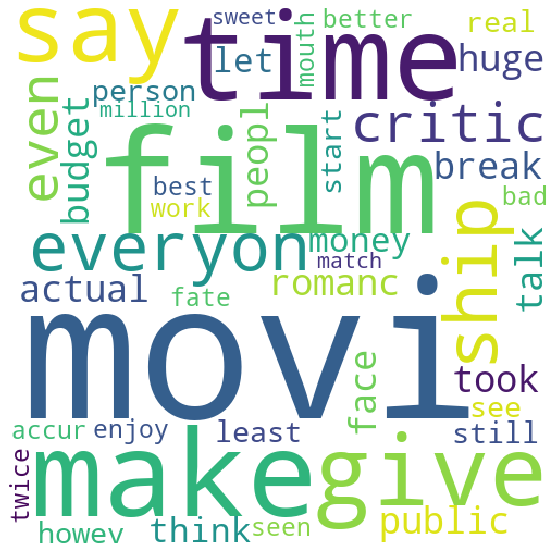

In [52]:
idx = 50
row = X_train_tfidf[idx]
terms = [(vocab_by_idx[row.indices[i]], row.data[i]) 
                 for i, term in enumerate(row.indices)]
top_terms= list(pd.Series(dict(terms))\
                .sort_values(ascending = False)[:50].index)
wc = WordCloud(background_color="white", 
    width=500, height=500, max_words=50).generate("+".join(top_terms))
plt.figure(figsize=(10, 10))
plt.imshow(wc)
plt.axis("off");

# Build Pipeline for classificaiton Model

In [53]:
%%time
tfidf =feature_extraction.text.TfidfVectorizer(
              tokenizer=my_tokenizer
            , stop_words = stopwords
            , ngram_range=(1, 2)
        )

pipe = pipeline.Pipeline([
    ("tfidf", tfidf),
    ("est", linear_model.LogisticRegression(C = 1.0, random_state = 1
                            , n_jobs = 8, solver="saga"))
])
pipe.fit(X_train, y_train)

/Users/abasar/anaconda3/lib/python3.7/site-packages/sklearn/feature_extraction/text.py:385: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['could', 'might', 'must', "n't", 'need', 'sha', 'would'] not in stop_words.
  'stop_words.' % sorted(inconsistent))


CPU times: user 1min 34s, sys: 784 ms, total: 1min 35s
Wall time: 1min 36s


Pipeline(memory=None,
         steps=[('tfidf',
                 TfidfVectorizer(analyzer='word', binary=False,
                                 decode_error='strict',
                                 dtype=<class 'numpy.float64'>,
                                 encoding='utf-8', input='content',
                                 lowercase=True, max_df=1.0, max_features=None,
                                 min_df=1, ngram_range=(1, 2), norm='l2',
                                 preprocessor=None, smooth_idf=True,
                                 stop_words=['i', 'me', 'my', 'myself', 'we',
                                             'our', 'ours', 'ourselves', 'you...
                                 token_pattern='(?u)\\b\\w\\w+\\b',
                                 tokenizer=<function my_tokenizer at 0x7fb80b877830>,
                                 use_idf=True, vocabulary=None)),
                ('est',
                 LogisticRegression(C=1.0, class_weight=None, dual=False,


In [54]:
import pickle

In [55]:
with open("/tmp/model.pkl", "wb") as f:
    pickle.dump(pipe, f)

In [56]:
!ls -lh /tmp/model.pkl

-rw-r--r--  1 abasar  wheel   122M Sep 25 11:45 /tmp/model.pkl


In [57]:
with open("/tmp/model.pkl", "rb") as f:
    model = pickle.load(f)

In [58]:
doc1 = """when we started watching this series on 
cable i had no idea how addictive it would be 
even when you hate a character you hold back because 
they are so beautifully developed you can almost
understand why they react to frustration fear greed 
or temptation the way they do it s almost as if the
viewer is experiencing one of christopher s learning 
curves i can t understand why adriana would put up with 
christopher s abuse of her verbally physically and 
emotionally but i just have to read the newspaper to 
see how many women can and do tolerate such behavior 
carmella has a dream house endless supply of expensive 
things but i m sure she would give it up for a loving 
and faithful husband or maybe not that s why i watch 
it doesn t matter how many times you watch an episode
you can find something you missed the first five times 
we even watch episodes out of sequence watch season 1 
on late night with commercials but all the language a e 
with language censored reruns on the movie network whenever 
they re on we re there we ve been totally spoiled now i also 
love the malaprop s an albacore around my neck is my favorite of
johnny boy when these jewels have entered our family vocabulary 
it is a sign that i should get a life i will when the series
ends and i have collected all the dvd s and put the collection 
in my will"""
doc1 = preprocess(doc1)

In [59]:
model.predict_proba(np.array([doc1]))[:, 1]

/Users/abasar/anaconda3/lib/python3.7/site-packages/sklearn/feature_extraction/text.py:385: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['could', 'might', 'must', "n't", 'need', 'sha', 'would'] not in stop_words.
  'stop_words.' % sorted(inconsistent))


array([0.8001])

# Hashing Vectorizer



Convert a collection of text documents to a matrix of deterministic hash token (murmur3) occurrences

It turns a collection of text documents into a scipy.sparse matrix holding token occurrence counts (or binary occurrence information), possibly normalized as token frequencies if norm=’l1’ or projected on the euclidean unit sphere if norm=’l2’.

Advantages 
- it is very low memory scalable to large datasets as there is no need to store a vocabulary dictionary in memory
- it is fast to pickle and un-pickle as it holds no state besides the constructor parameters
- it can be used in a streaming (partial fit) or parallel pipeline as there is no state computed during fit.

Disadvantages
- there is no way to compute the inverse transform (from feature indices to string feature names) which can be a problem when trying to introspect which features are most important to a model.
- there can be collisions: distinct tokens can be mapped to the same feature index. However in practice this is rarely an issue if n_features is large enough (e.g. 2 ** 18 for text classification problems).
- no IDF weighting as this would render the transformer stateful.

In [60]:
hashing_vectorizer = feature_extraction.text.HashingVectorizer(n_features=2 ** 3
                                            , tokenizer=my_tokenizer, ngram_range=(1, 2))

corpus = ["Today is Wednesday"
          , "Delhi weather is hot today."
          , "Delhi roads are not busy in the morning"]

doc_term_matrix = hashing_vectorizer.fit_transform(corpus)

pd.DataFrame(doc_term_matrix.toarray()) # Each cell is normalized (l2) row-wise


/Users/abasar/anaconda3/lib/python3.7/site-packages/sklearn/feature_extraction/text.py:507: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn("The parameter 'token_pattern' will not be used"


,0,1,2,3,4,5,6,7
0,0.0000,0.5774,0.0000,0.5774,0.0000,0.0000,-0.5774,0.0000
1,0.0000,0.3780,0.7559,0.0000,0.0000,-0.3780,-0.3780,0.0000
2,0.0000,-0.4472,0.0000,0.0000,0.4472,-0.4472,-0.4472,0.4472


In [61]:
%%time

n_features = int(X_train_tfidf.shape[1] * 0.8)

hashing_vectorizer = feature_extraction.text.HashingVectorizer(n_features=n_features
                                         , tokenizer=my_tokenizer, ngram_range=(1, 2))
X_train_hash = hashing_vectorizer.fit_transform(X_train)
X_test_hash = hashing_vectorizer.transform(X_test)

/Users/abasar/anaconda3/lib/python3.7/site-packages/sklearn/feature_extraction/text.py:507: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn("The parameter 'token_pattern' will not be used"


CPU times: user 2min 23s, sys: 468 ms, total: 2min 23s
Wall time: 2min 24s


In [62]:
X_train_hash

<25000x1418 sparse matrix of type '<class 'numpy.float64'>'
	with 4719643 stored elements in Compressed Sparse Row format>

In [63]:
X_train_hash.shape, X_test_hash.shape

((25000, 1418), (25000, 1418))

In [64]:
print(X_train_hash.data.nbytes / (1024.0 ** 3), "GB")

0.03516408056020737 GB


In [65]:
%%time
lr = linear_model.LogisticRegression(C = 1.0, random_state = 1,
                            solver = "liblinear")
lr.fit(X_train_hash, y_train)
y_train_pred = lr.predict(X_train_hash)
y_test_pred = lr.predict(X_test_hash)
print("Training accuracy: ", metrics.accuracy_score(y_train, y_train_pred))
print("Test accuracy: ", metrics.accuracy_score(y_test, y_test_pred))

Training accuracy:  0.82604
Test accuracy:  0.8004
CPU times: user 631 ms, sys: 25.4 ms, total: 657 ms
Wall time: 658 ms


In [66]:
print(metrics.classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.80      0.80      0.80     12500
           1       0.80      0.81      0.80     12500

    accuracy                           0.80     25000
   macro avg       0.80      0.80      0.80     25000
weighted avg       0.80      0.80      0.80     25000

